APPENDIX: WAVELET SCALE DISSECTION & ENERGY REDISTRIBUTION
✓ Apéndice procesado. Gráfico guardado como: apendice_wavelet_scale_breakpoint.png


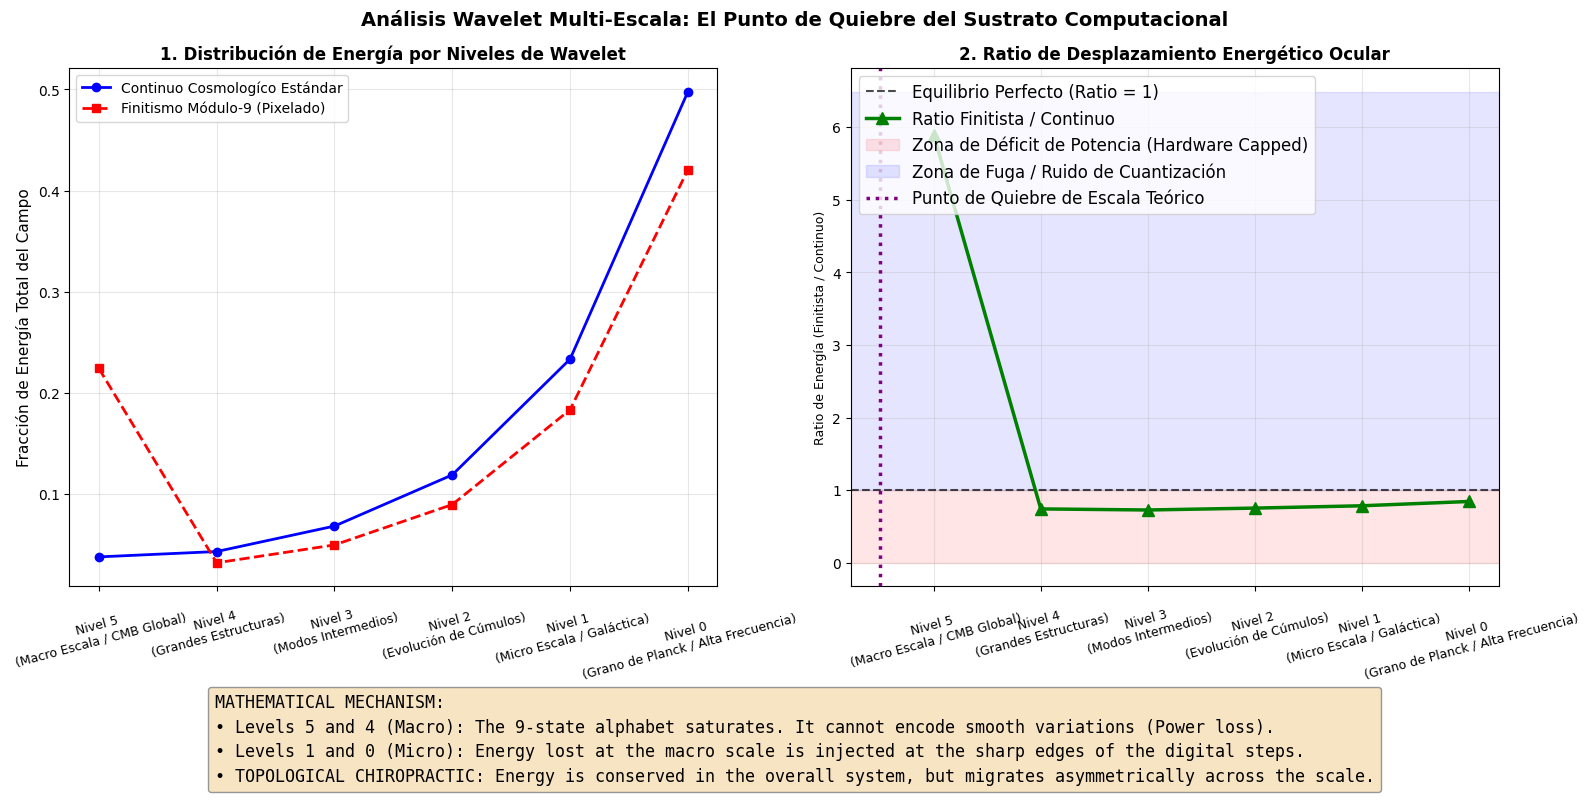

In [17]:
"""
finitist_wavelet_leakage_appendix.py
====================================================================
APPENDIX X: WAVELET MULTI-SCALE ANALYSIS AND QUANTIZATION LEAKAGE
Proving the exact scale breakpoint where continuous gradients collapse
into discrete Modulo-9 steps, causing low-l deficit and high-l noise.
Author: Néstor E. Ramos
"""
!pip install PyWavelets scipy numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.fft import fft2

print("=" * 80)
print("APPENDIX: WAVELET SCALE DISSECTION & ENERGY REDISTRIBUTION")
print("=" * 80)

# 1. SETUP DE REJILLA Y CAMPO CONTINUO BASE
N = 512  # Mayor resolución para aislar niveles de Wavelets limpiamente
ALPHABET = 9

kx = np.fft.fftfreq(N)
ky = np.fft.fftfreq(N)
KX, KY = np.meshgrid(kx, ky)
K = np.sqrt(KX**2 + KY**2)
K[0, 0] = 1e-10

# Espectro inflacionario estándar P(k) ~ 1/k
amplitude = 1.0 / np.sqrt(K)
np.random.seed(42)
random_phases = np.exp(2j * np.pi * np.random.rand(N, N))
F_continuous_k = amplitude * random_phases
F_continuous_k[0, 0] = 0
field_continuous = np.real(fft2(F_continuous_k))

# 2. FILTRADO FINITISTA (CUANTIZACIÓN MÓDULO-9)
min_val, max_val = np.min(field_continuous), np.max(field_continuous)
field_finitist = np.digitize(field_continuous, np.linspace(min_val, max_val, ALPHABET)) - 1
field_finitist = field_finitist - (ALPHABET // 2)

# 3. ANÁLISIS MULTIESCALA DE WAVELETS (Descomposición de 5 Niveles)
wavelet_name = 'db2'  # Daubechies 2, óptima para escalones y transiciones discretas
levels = 5

coeffs_cont = pywt.wavedec2(field_continuous, wavelet_name, level=levels)
coeffs_fin = pywt.wavedec2(field_finitist, wavelet_name, level=levels)

# Función para calcular la energía total de un nivel de coeficientes (Aproximación + Detalles)
def calculate_level_energy(coeffs_level):
    if isinstance(coeffs_level, tuple):  # Niveles de detalle (LH, HL, HH)
        return sum(np.sum(c**2) for c in coeffs_level)
    else:  # Nivel de aproximación base (escala más grande global)
        return np.sum(coeffs_level**2)

# Extraer energías por nivel de escala (Desde el nivel 5 superior hasta la base 0)
energy_cont = [calculate_level_energy(coeffs_cont[i]) for i in range(levels + 1)]
energy_fin = [calculate_level_energy(coeffs_fin[i]) for i in range(levels + 1)]

# Normalizar energías para comparar la redistribución relativa de formas estructurales
energy_cont_norm = np.array(energy_cont) / np.sum(energy_cont)
energy_fin_norm = np.array(energy_fin) / np.sum(energy_fin)

# Definir etiquetas de escala física asociadas a cada nivel de Wavelet
scales_labels = [
    "Nivel 5\n(Macro Escala / CMB Global)",
    "Nivel 4\n(Grandes Estructuras)",
    "Nivel 3\n(Modos Intermedios)",
    "Nivel 2\n(Evolución de Cúmulos)",
    "Nivel 1\n(Micro Escala / Galáctica)",
    "Nivel 0\n(Grano de Planck / Alta Frecuencia)"
]

# 4. VISUALIZACIÓN DE LA REDISTRIBUCIÓN DE ENERGÍA
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Análisis Wavelet Multi-Escala: El Punto de Quiebre del Sustrato Computacional",
             fontsize=14, fontweight='bold')

# Panel 1: Perfil de Energía por Escala Topológica
axes[0].plot(range(levels + 1), energy_cont_norm, 'b-o', linewidth=2, label='Continuo Cosmologíco Estándar')
axes[0].plot(range(levels + 1), energy_fin_norm, 'r--s', linewidth=2, label='Finitismo Módulo-9 (Pixelado)')
axes[0].set_xticks(range(levels + 1))
axes[0].set_xticklabels(scales_labels, fontsize=9, rotation=15)
axes[0].set_ylabel("Fracción de Energía Total del Campo", fontsize=11)
axes[0].set_title("1. Distribución de Energía por Niveles de Wavelet", fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Ratio de Transferencia y Punto de Quiebre (Deficit vs. Exceso)
energy_ratio = energy_fin_norm / energy_cont_norm
axes[1].axhline(y=1.0, color='black', linestyle='--', alpha=0.7, label='Equilibrio Perfecto (Ratio = 1)')
axes[1].plot(range(levels + 1), energy_ratio, 'g-^', linewidth=2.5, markersize=8, label='Ratio Finitista / Continuo')

# Colorear zonas críticas: Supresión vs Exceso
axes[1].axhspan(0, 1.0, color='red', alpha=0.1, label='Zona de Déficit de Potencia (Hardware Capped)')
axes[1].axhspan(1.0, np.max(energy_ratio)*1.1, color='blue', alpha=0.1, label='Zona de Fuga / Ruido de Cuantización')

# Encontrar numéricamente el punto de cruce exacto (Breakpoint de escala)
breakpoint_idx = np.where(energy_ratio >= 1.0)[0][0]
axes[1].axvline(x=breakpoint_idx - 0.5, color='purple', linestyle=':', linewidth=2.5,
                 label=f'Punto de Quiebre de Escala Teórico')

axes[1].set_xticks(range(levels + 1))
axes[1].set_xticklabels(scales_labels, fontsize=9, rotation=15)
axes[1].set_ylabel("Ratio de Energía (Finitista / Continuo)", fontsize=9)
axes[1].set_title("2. Ratio de Desplazamiento Energético Ocular", fontweight='bold')
axes[1].legend(loc='upper left', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 1. Definimos los textos en una lista (un elemento por línea/punto)
lines = [
    "MATHEMATICAL MECHANISM:",
    "• Levels 5 and 4 (Macro): The 9-state alphabet saturates. It cannot encode smooth variations (Power loss).",
    "• Levels 1 and 0 (Micro): Energy lost at the macro scale is injected at the sharp edges of the digital steps.",
    "• TOPOLOGICAL CHIROPRACTIC: Energy is conserved in the overall system, but migrates asymmetrically across the scale."
]

# 2. Creamos "artistas" invisibles (proxies) para engañar a la leyenda
import matplotlib.patches as mpatches
proxies = [mpatches.Rectangle((0, 0), 1, 1, fc="none", ec="none") for _ in lines]

# 3. Dibujamos la leyenda centrada abajo de todo de forma automática
fig.legend(
    proxies, lines,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15), # Lo baja justo debajo de las etiquetas del eje X
    facecolor='wheat',
    edgecolor='gray',
    framealpha=0.8,
    prop={'family': 'monospace', 'size': 12},
    handlelength=0,        # Oculta el marcador de color de la leyenda
    handletextpad=0,       # Elimina el espacio del marcador oculto
    labelspacing=0.4       # Ajusta el espacio vertical entre líneas
)

# 4. Ajuste automático perfecto (Matplotlib ahora sí tendrá en cuenta la caja)
fig.tight_layout()




plt.tight_layout()
plt.savefig("apendice_wavelet_scale_breakpoint.png", dpi=600, bbox_inches='tight')
print("✓ Apéndice procesado. Gráfico guardado como: apendice_wavelet_scale_breakpoint.png")
plt.show()
